In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt

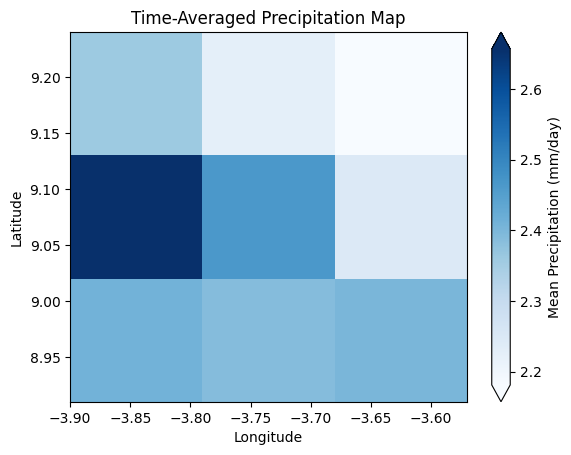

In [2]:
file_path ='data/ClimateScenarios/pr/Aas_prAdjust_NORDIC-11_CNRM-CERFACS-CNRM-CM5_rcp26_r1i1p1_CNRM-ALADIN63_v2_day_19510101-21001231.nc'

# Compute time-mean precipitation
ds = xr.open_dataset(file_path)
mean_map = ds['pr'].mean(dim='time')* 86400 #mm/day

# Plot the map
mean_map.plot(
    x='rlon', y='rlat',
    cmap='Blues',
    cbar_kwargs={'label': 'Mean Precipitation (mm/day)'},
    robust=True
)
plt.title('Time-Averaged Precipitation Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [3]:
#Precipitation 
# Folder containing NetCDF files
folder_path = 'data/ClimateScenarios/pr'
output_path = 'data/ClimateScenarios/pr/pr_As_merged.nc'

# List all .nc files in the folder
nc_files = [f for f in os.listdir(folder_path) if f.endswith('.nc')]
datasets = []

# Reference coords
ref_ds = xr.open_dataset(os.path.join(folder_path, nc_files[0]))
ref_rlat = ref_ds['rlat']
ref_rlon = ref_ds['rlon']
ref_lat = ref_ds['latitude']
ref_lon = ref_ds['longitude']

for fname in nc_files:
    full_path = os.path.join(folder_path, fname)

    try:
        model_tag = fname.split('NORDIC-11')[1].split('_day')[0].strip('_')
    except IndexError:
        print(f"Skipping {fname}: model_tag not found")
        continue

    rcp_parts = [part for part in fname.split('_') if part.startswith('rcp')]
    rcp_tag = rcp_parts[0] if rcp_parts else 'unknown_rcp'

    ds = xr.open_dataset(full_path)

    # Keep original rlat y rlon
    ds = ds.assign_coords(rlat=ref_rlat, rlon=ref_rlon)
    ds['latitude'] = ref_lat
    ds['longitude'] = ref_lon

    # Tags as coordinates
    ds = ds.expand_dims({'source': [f'{model_tag}_{rcp_tag}']})
    ds = ds.assign_coords(model_tag=('source', [model_tag]), rcp_tag=('source', [rcp_tag]))

    datasets.append(ds)

# Concat upon 'source'
merged = xr.concat(datasets, dim='source')

# Explicit dimentions
merged = merged.set_index(source=['model_tag', 'rcp_tag']).unstack('source')

# Save merged dataset
merged.to_netcdf(output_path)

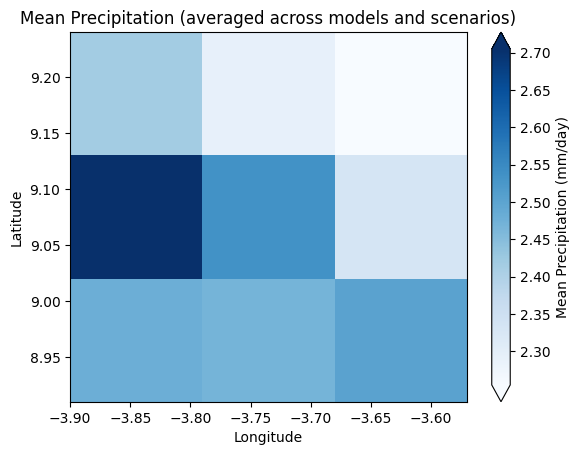

In [4]:
test = merged['pr'].mean(dim=['time', 'model_tag', 'rcp_tag']) * 86400  # Convertir a mm/day
# Plot the mean precipitation map
test.plot(
    x='rlon', y='rlat',
    cmap='Blues',
    cbar_kwargs={'label': 'Mean Precipitation (mm/day)'},
    robust=True
)
plt.title('Mean Precipitation (averaged across models and scenarios)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [5]:
# Temperature
# Folder containing NetCDF files
folder_path = 'data/ClimateScenarios/tas'
output_path = 'data/ClimateScenarios/tas/tas_As_merged.nc'

# List all .nc files in the folder
nc_files = [f for f in os.listdir(folder_path) if f.endswith('.nc')]
datasets = []

# Reference coords
ref_ds = xr.open_dataset(os.path.join(folder_path, nc_files[0]))
ref_rlat = ref_ds['rlat']
ref_rlon = ref_ds['rlon']
ref_lat = ref_ds['latitude']
ref_lon = ref_ds['longitude']

for fname in nc_files:
    full_path = os.path.join(folder_path, fname)

    try:
        model_tag = fname.split('NORDIC-11')[1].split('_day')[0].strip('_')
    except IndexError:
        print(f"Skipping {fname}: model_tag not found")
        continue

    rcp_parts = [part for part in fname.split('_') if part.startswith('rcp')]
    rcp_tag = rcp_parts[0] if rcp_parts else 'unknown_rcp'

    ds = xr.open_dataset(full_path)

    # Keep original rlat y rlon
    ds = ds.assign_coords(rlat=ref_rlat, rlon=ref_rlon)
    ds['latitude'] = ref_lat
    ds['longitude'] = ref_lon

    # Tags as coordinates
    #ds = ds.expand_dims({'source': [f'{model_tag}_{rcp_tag}']})
    ds = ds.expand_dims({'source': [f'{model_tag}_{rcp_tag}']})
    ds = ds.assign_coords(model_tag=('source', [model_tag]), rcp_tag=('source', [rcp_tag]))

    datasets.append(ds)

# Concat upon 'source'
merged = xr.concat(datasets, dim='source')

# Explicit dimentions
merged = merged.set_index(source=['model_tag', 'rcp_tag']).unstack('source')

# Save merged dataset
merged.to_netcdf(output_path)

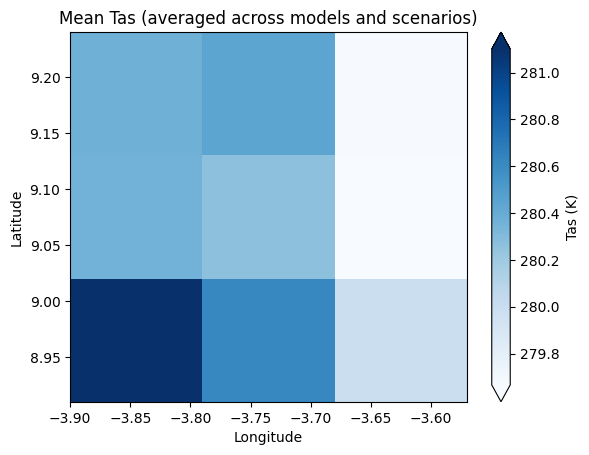

In [6]:
test = merged['tas'].mean(dim=['time', 'model_tag', 'rcp_tag']) 
# Plot the mean precipitation map
test.plot(
    x='rlon', y='rlat',
    cmap='Blues',
    cbar_kwargs={'label': 'Tas (K)'},
    robust=True
)
plt.title('Mean Tas (averaged across models and scenarios)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()